In [1]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [2]:
import src.loader.load as load_module
reload(load_module)
load_data = load_module.load_data

In [3]:
data = load_data(r"./dummy_data/single/dummy_cell_tracks.csv", {'id': 'track_id', 'x': 'x_coordinate', 'y': 'y_coordinate', 't': 'time_point'}, spatial_unit="micrometer", time_unit="second")

In [24]:
import src.compute.stats as stats_module
reload(stats_module)
create_object = stats_module.create_object

In [25]:
data_object = create_object(data)

In [12]:
data_object.compute_spots()

track_id,time_point,x_coordinate,y_coordinate,set,track_uid,frame,distance,cum_track_length,cum_track_displacement,cum_straightness_ratio,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
f64,f64,f64,f64,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,3.0,137.514149,236.600293,"""dummy_cell_tracks.csv""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1.0,4.0,139.127447,237.661942,"""dummy_cell_tracks.csv""",0,1,1.931277,1.931277,1.931277,1.0,1.931277,0.965639,0.5,0.582021,null,null,null,null,0.582021,0.0
1.0,5.0,140.356463,240.406687,"""dummy_cell_tracks.csv""",0,2,3.007341,4.938619,4.750514,0.961912,2.469309,1.583505,0.641274,1.149798,32.531211,32.531211,32.531211,10.843737,0.86591,0.040026
1.0,6.0,140.903109,242.203982,"""dummy_cell_tracks.csv""",0,3,1.878587,6.817206,6.548769,0.960624,2.272402,1.637192,0.720468,1.275537,7.204319,39.735531,19.867765,4.966941,1.005371,0.044989
1.0,7.0,143.090242,243.676198,"""dummy_cell_tracks.csv""",0,4,2.63647,9.453676,9.008954,0.952958,2.363419,1.801791,0.762366,0.592461,39.137384,78.872915,26.290972,5.258194,0.899637,0.049444
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
24.0,95.0,-3.017567,285.431985,"""dummy_cell_tracks.csv""",23,95,2.500757,232.417741,106.135482,0.456658,2.446503,1.105578,0.451901,-2.274176,3.916471,2484.478776,26.430625,0.275319,-3.085176,0.536443
24.0,96.0,-5.199282,285.070131,"""dummy_cell_tracks.csv""",23,96,2.21152,234.629261,108.315709,0.461646,2.444055,1.116657,0.456887,-2.977232,40.282134,2524.76091,26.576431,0.273984,-3.082784,0.530914
24.0,97.0,-7.089226,285.753609,"""dummy_cell_tracks.csv""",23,97,2.009734,236.638995,110.209342,0.465728,2.439577,1.124585,0.460975,2.794587,29.299176,2554.060086,26.604793,0.271477,-3.091375,0.526261


In [11]:
tracks = data_object.compute_tracks()
tracks

set,track_uid,speed_min,speed_max,speed_mean,speed_sd,speed_median,track_length,x_location,y_location,max_distance_reached,track_start_frame,track_end_frame,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_points,track_displacement,straightness_ratio,track_id
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64
"""dummy_cell_tracks.csv""",0,1.233776,4.252455,2.680976,0.762023,2.673782,257.373703,205.447064,231.546034,117.503971,0,96,0.4731,0.176466,0.443917,0.829524,22.664884,0.233659,97,45.890725,0.178304,1.0
"""dummy_cell_tracks.csv""",1,2.171651,7.239426,4.388412,0.909812,4.364766,434.452812,490.938591,559.58178,332.384607,0,99,3.323846,0.757414,1.366624,0.226892,13.167909,0.131679,100,332.384607,0.765065,2.0
"""dummy_cell_tracks.csv""",2,3.902545,11.37175,7.631483,1.630856,7.691069,755.516769,15.68079,-247.466824,726.930595,0,99,7.269306,0.952542,-1.911028,0.039041,5.423314,0.054233,100,726.930595,0.962163,3.0
"""dummy_cell_tracks.csv""",3,0.936632,3.706162,2.327591,0.631985,2.303685,230.431533,58.813657,159.087233,200.038054,0,99,2.000381,0.859421,1.208485,0.134173,16.355813,0.163558,100,200.038054,0.868102,4.0
"""dummy_cell_tracks.csv""",4,3.280677,10.68337,6.668594,1.488335,6.669109,660.19081,368.768117,272.297316,312.768603,0,99,2.813495,0.421902,0.232892,0.569961,19.788626,0.197886,100,281.34948,0.426164,5.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""dummy_cell_tracks.csv""",19,1.709629,8.499498,5.357302,1.17141,5.469928,530.372878,249.230977,456.544769,461.856736,0,99,4.618567,0.862107,1.11706,0.130355,9.604537,0.096045,100,461.856736,0.870815,20.0
"""dummy_cell_tracks.csv""",20,1.919261,8.121097,5.249989,1.14617,5.210686,519.748946,439.98527,456.070235,482.809129,0,99,4.828091,0.919638,0.536905,0.074864,13.918959,0.13919,100,482.809129,0.928928,21.0
"""dummy_cell_tracks.csv""",21,1.201748,5.099428,2.869523,0.672151,2.891775,284.082813,388.971536,-48.972826,217.881464,0,99,2.172907,0.757236,-1.300468,0.251225,20.394153,0.203942,100,217.290654,0.764885,22.0



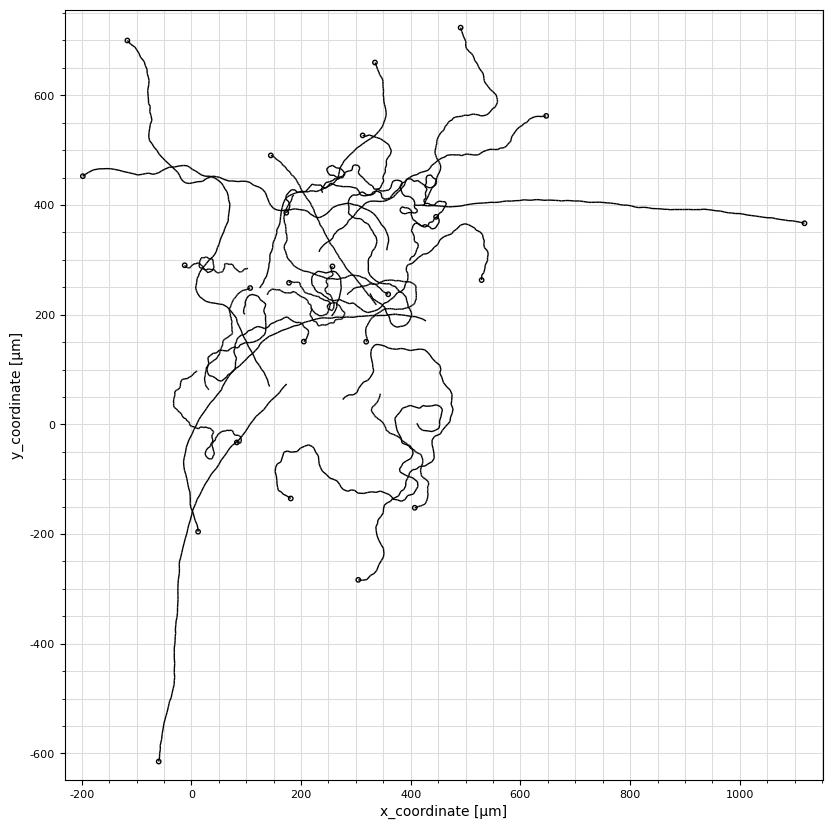

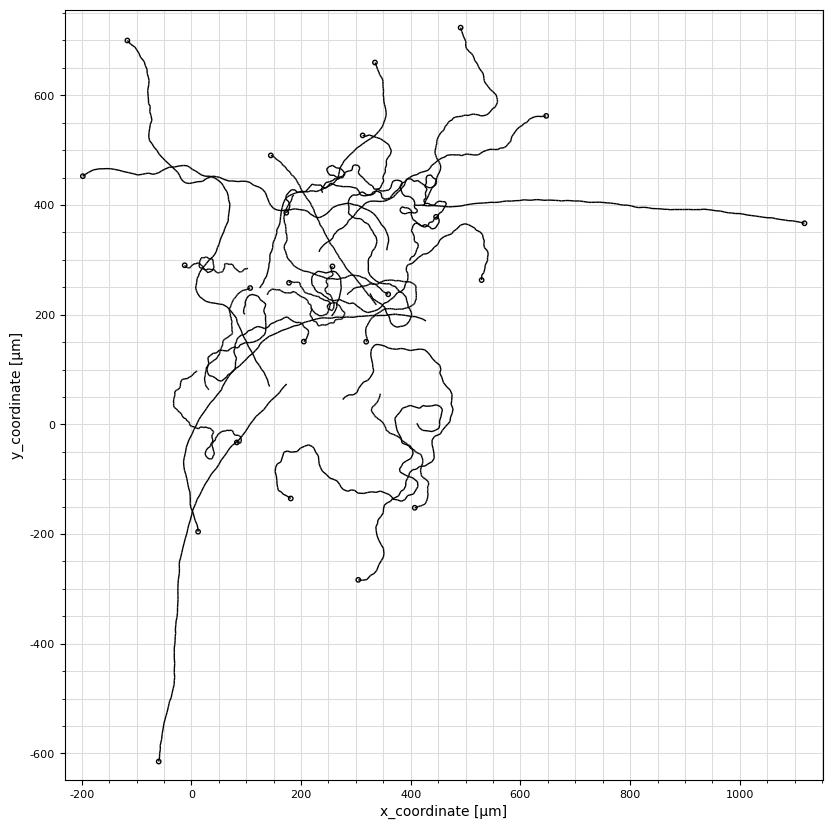

In [13]:
data_object.plot_tracks()

In [27]:
data_object.compute_timepoints()

set,time_point,frame,cum_track_length_min,cum_track_length_max,cum_track_length_mean,cum_track_length_median,cum_track_length_sd,cum_track_displacement_min,cum_track_displacement_max,cum_track_displacement_mean,cum_track_displacement_median,cum_track_displacement_sd,cum_straightness_ratio_min,cum_straightness_ratio_max,cum_straightness_ratio_mean,cum_straightness_ratio_median,cum_straightness_ratio_sd,cum_speed_mean_min,cum_speed_mean_max,cum_speed_mean_mean,cum_speed_mean_median,cum_speed_mean_sd,instantaneous_speed_min,instantaneous_speed_max,instantaneous_speed_mean,instantaneous_speed_median,instantaneous_speed_sd,cum_mean_straight_line_speed_min,cum_mean_straight_line_speed_max,cum_mean_straight_line_speed_mean,cum_mean_straight_line_speed_median,cum_mean_straight_line_speed_sd,cum_forward_progression_linearity_min,cum_forward_progression_linearity_max,cum_forward_progression_linearity_mean,cum_forward_progression_linearity_median,cum_forward_progression_linearity_sd,cum_sum_directional_change_min,cum_sum_directional_change_max,cum_sum_directional_change_mean,cum_sum_directional_change_median,cum_sum_directional_change_sd,cum_mean_directional_change_min,cum_mean_directional_change_max,cum_mean_directional_change_mean,cum_mean_directional_change_median,cum_mean_directional_change_sd,instantaneous_direction_mean,instantaneous_direction_var,cum_direction_mean,cum_direction_var,grouping_level
str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""dummy_cell_tracks.csv""",3.0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""set"""
"""dummy_cell_tracks.csv""",4.0,1,1.931277,1.931277,1.931277,1.931277,null,1.931277,1.931277,1.931277,1.931277,null,1.0,1.0,1.0,1.0,null,1.931277,1.931277,1.931277,1.931277,null,1.931277,1.931277,1.931277,1.931277,null,0.965639,0.965639,0.965639,0.965639,null,0.5,0.5,0.5,0.5,null,null,null,null,null,null,null,null,null,null,null,0.582021,0.0,0.582021,0.0,"""set"""
"""dummy_cell_tracks.csv""",5.0,2,4.938619,4.938619,4.938619,4.938619,null,4.750514,4.750514,4.750514,4.750514,null,0.961912,0.961912,0.961912,0.961912,null,2.469309,2.469309,2.469309,2.469309,null,3.007341,3.007341,3.007341,3.007341,null,1.583505,1.583505,1.583505,1.583505,null,0.641274,0.641274,0.641274,0.641274,null,32.531211,32.531211,32.531211,32.531211,null,32.531211,32.531211,32.531211,32.531211,null,1.149798,0.0,0.86591,0.0,"""set"""
"""dummy_cell_tracks.csv""",6.0,3,6.817206,6.817206,6.817206,6.817206,null,6.548769,6.548769,6.548769,6.548769,null,0.960624,0.960624,0.960624,0.960624,null,2.272402,2.272402,2.272402,2.272402,null,1.878587,1.878587,1.878587,1.878587,null,1.637192,1.637192,1.637192,1.637192,null,0.720468,0.720468,0.720468,0.720468,null,39.735531,39.735531,39.735531,39.735531,null,19.867765,19.867765,19.867765,19.867765,null,1.275537,0.0,1.005371,0.0,"""set"""
"""dummy_cell_tracks.csv""",7.0,4,9.453676,9.453676,9.453676,9.453676,null,9.008954,9.008954,9.008954,9.008954,null,0.952958,0.952958,0.952958,0.952958,null,2.363419,2.363419,2.363419,2.363419,null,2.63647,2.63647,2.63647,2.63647,null,1.801791,1.801791,1.801791,1.801791,null,0.762366,0.762366,0.762366,0.762366,null,78.872915,78.872915,78.872915,78.872915,null,26.290972,26.290972,26.290972,26.290972,null,0.592461,0.0,0.899637,0.0,"""set"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""dummy_cell_tracks.csv""",95.0,95,220.265245,748.977405,504.721869,556.724973,186.0915,64.493709,698.206756,307.328832,284.548199,196.919377,0.110414,0.993841,0.607093,0.733218,0.28865,2.318582,7.883973,5.312862,5.860263,1.958858,1.646618,9.999368,5.306028,5.284202,2.440

In [26]:
data_object.compute_timelags()

set,frame_lag,time_lag,MSD,MSD_sd,tracks_contributing,position_pairs_contributing,directional_change_mean,directional_change_var,grouping_level
str,i64,f64,f64,f64,i64,i64,f64,f64,str
"""dummy_cell_tracks.csv""",1,1.0,32.402382,26.35103,24,2373,0.199047,0.077267,"""set"""
"""dummy_cell_tracks.csv""",2,2.0,122.382956,90.9848,24,2349,0.570219,0.126224,"""set"""
"""dummy_cell_tracks.csv""",3,3.0,266.872794,192.354841,24,2325,0.855268,0.171627,"""set"""
"""dummy_cell_tracks.csv""",4,4.0,462.908742,330.071884,24,2301,1.487436,0.215373,"""set"""
"""dummy_cell_tracks.csv""",5,5.0,707.482384,503.098271,24,2277,1.826799,0.25443,"""set"""
…,…,…,…,…,…,…,…,…,…
"""dummy_cell_tracks.csv""",95,95.0,129693.652374,143420.11444,24,117,31.98907,0.910505,"""set"""
"""dummy_cell_tracks.csv""",96,96.0,132617.007533,146653.844959,24,93,54.743342,0.909688,"""set"""
"""dummy_cell_tracks.csv""",97,97.0,136120.332062,150049.832599,23,69,84.88742,0.853847,"""set"""
